## SCRIPT TO PRODUCE FIGURES FROM MSE / STABILITY / RAINY DAY CATEGORY ANALYSIS

In [1]:
import xarray as xr
import numpy as np
import cartopy
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import sys
sys.path.append('/home/pfernand/Postdoc/Python_scripts/')
from WAM_functions import *
from Forced_simulation_functions import *
from scipy import stats
import numpy.ma as ma
import matplotlib.mlab as mlab
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import BoundaryNorm
import scipy
import matplotlib.patches as patches
import metpy.calc as mpcalc
from metpy.units import units
import cftime
from regr_sig import *
from regr_2d_ttest import *
import xskillscore
from matplotlib.lines import Line2D
from scipy.stats import ttest_rel
from pyextremes import EVA
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from matplotlib.ticker import MultipleLocator

In [2]:
###### PARÁMETROS IMPORTANTES #######

sahel_box_west_tot = {'lat_min':12.5, 'lat_max':17, 'lon_min':-17, 'lon_max':-10}
sahel_box_east_tot = {'lat_min':8, 'lat_max':17, 'lon_min':5, 'lon_max':10}
sahel_box = {'lat_min':8, 'lat_max':17, 'lon_min':-17, 'lon_max':10}
WA_box = {'lat_min':-40, 'lat_max':40, 'lon_min':-50, 'lon_max':50}


time_limits = ['1980-07-01T12:00:00.000000000', '2050-09-30T12:00:00.000000000']


#######################################
font = {'family' : 'calibri',
       'weight': 'bold',
       'size': 70}
plt.rc('font', **font)
plt.rc('axes',edgecolor='k',linewidth=3)

In [10]:
################### FUNCTIONS ####################

def n_I_rainy_days(ds, variable, threshold):

    """ Función que calcula el número de días lluviosos y su intensidad por año así como la cantidad de precipitación caída durante los días no lluviosos """


    ds['masked_rainy'] = xr.where(ds.pr > threshold, 1, 0)
    ds['masked_rain'] = xr.where(ds.pr > 0, 1, 0)
    ds['all_rainy'] = xr.where(ds.pr > threshold, 1, 1)
    ds['perc_rainy'] = ds.masked_rainy.sum(dim = ['lat','lon'], skipna = True) / ds.all_rainy.sum(dim = ['lat','lon'], skipna = True)
    ds['masked_nonrainy'] = xr.where(ds.pr <= threshold, 1, 0)
    ds['pr_rainy'] = xr.where(ds.pr > threshold, ds.pr, 0)
    ds['I_rainy'] = xr.where(ds.pr > threshold, ds.pr, np.nan)
    ds['pr_rainy_cum_yr'] = ds.pr_rainy.groupby('time.year').sum(dim = 'time', skipna = True)
    ds['n_rainy'] = ds.masked_rainy.groupby('time.year').sum(dim = 'time', skipna = True)
    ds['I_rainy_yr'] = ds.pr_rainy_cum_yr / ds.n_rainy
    ds['pr_nonrainy_cum_yr'] = xr.where(ds.pr <= threshold, ds.pr, 0).groupby('time.year').sum(dim = 'time', skipna = True)
    ds['pr_cum_yr'] = ds.pr.groupby('time.year').sum(dim = 'time', skipna = True)

    return ds

def qsatcoare36(T,P,RH,Tf):
    # Calcula la humedad espcífica de saturación con T en grados, P en hPa, RH en % y Tf = 0 (punto de fusión)
    mask = xr.where(T<Tf, 1, 0)
    exx = xr.where(T<Tf, np.multiply(np.multiply((1.0003 + 4.18e-06 * P),6.1115),np.exp(np.multiply(22.452,T) / (T + 272.55))), np.multiply(np.multiply(6.1121,np.exp(np.multiply(17.502,T) / (T + 240.97))),(1.0007 + np.multiply(3.46e-06,P)))) 
    em = np.multiply(0.01 * RH,exx)
    qsat = 622 * em / (P - 0.378 * em)

    return qsat

def area_weighted_mean(ds,var):
    area_grid_cell, dx, dy = area_grid(ds.lat, ds.lon)
    #area_grid_cell = xr.where(np.isnan(ds), np.nan, area_grid_cell)
    area_region = area_grid_cell.sum(dim = ['lat', 'lon'], skipna = True)
    area_weighted_mean_result = (ds[var] * area_grid_cell / area_region).sum(dim = ['lat', 'lon'], skipna = True)
    return area_weighted_mean_result


def temperature_from_specific_humidity(q, rh, pressure_hpa):
    """
    Calculate air temperature from specific humidity and relative humidity.

    Parameters
    ----------
    q : float or ndarray
        Specific humidity (kg/kg)
    rh : float or ndarray
        Relative humidity (%)
    pressure_hpa : float or ndarray
        Air pressure (hPa)

    Returns
    -------
    T : float or ndarray
        Air temperature (°C)
    """

    # Convert pressure to actual vapor pressure (hPa)
    e = (q * pressure_hpa) / (0.622 + 0.378 * q)

    # Saturation vapor pressure (hPa)
    es = e / (rh / 100.0)

    # Magnus formula inversion
    ln_ratio = np.log(es / 6.112)
    
    T = (243.5 * ln_ratio) / (17.67 - ln_ratio)

    return T


def WAM_moderate_heavy_extreme_difquant_forced(ds, variable, threshold):

    """ Función que calcula el número de días con eventos moderados, fuertes y extremos con percentiles calculados con todos los miembros de una simulación a lo largo de todos los tiempos, variable es la precipitación en mm/day. 
    Para la simulación acoplada utilizamos todos los tiempos.
    Para las simulationes forzadas, el umbral se calcula con la simulación de control y se aplica a las variantes DA y OM."""

    only_wet_days = xr.where((ds[variable] > threshold), ds[variable], np.nan)
    

    # También saco el año de incio

    if 'member' in list(ds.dims):
        perc_95 = only_wet_days.quantile(0.95, dim = ('time','member','simulation'), skipna = True)
        perc_75 = only_wet_days.quantile(0.75, dim = ('time','member', 'simulation'), skipna = True)
        
        ds['n_extreme'] = ((only_wet_days > perc_95.values)).groupby('time.year').sum(dim = 'time', skipna = True)
        ds['n_heavy'] = ((only_wet_days >= perc_75.values)).groupby('time.year').sum(dim = 'time', skipna = True)
        ds['n_moderate'] = ((only_wet_days < perc_75.values)).groupby('time.year').sum(dim = 'time', skipna = True)

        return ds


    if 'simulation' not in list(ds.dims):
        perc_95 = only_wet_days.quantile(0.95, dim = ('time'), skipna = True)
        perc_75 = only_wet_days.quantile(0.75, dim = ('time'), skipna = True)
        
        ds['n_extreme'] = ((only_wet_days > perc_95.values)).groupby('time.year').sum(dim = 'time', skipna = True)
        ds['n_heavy'] = ((only_wet_days >= perc_75.values)).groupby('time.year').sum(dim = 'time', skipna = True)
        ds['n_moderate'] = ((only_wet_days < perc_75.values)).groupby('time.year').sum(dim = 'time', skipna = True)

        return ds


    else:     
        perc_95 = only_wet_days.isel(simulation = [0]).quantile(0.95, dim = ('time', 'simulation'), skipna = True)
        perc_75 = only_wet_days.isel(simulation = [0]).quantile(0.75, dim = ('time', 'simulation'), skipna = True)
        
        ds['n_extreme'] = ((only_wet_days > perc_95.values)).groupby('time.year').sum(dim = 'time', skipna = True)
        ds['n_heavy'] = ((only_wet_days >= perc_75.values)).groupby('time.year').sum(dim = 'time', skipna = True)
        ds['n_moderate'] = ((only_wet_days < perc_75.values)).groupby('time.year').sum(dim = 'time', skipna = True)

        # Máscara a las categorías

        ds['extreme_mask'] = xr.where(only_wet_days > perc_95.values,3,np.nan)
        ds['heavy_mask'] = xr.where(only_wet_days >= perc_75.values,2,np.nan)
        ds['moderate_mask'] = xr.where(only_wet_days < perc_75.values,1,np.nan)
        ds['non_rainy_mask'] = xr.where((ds[variable] < threshold),0,np.nan)


        return ds, perc_95, perc_75

# Notebook to reproduce figures from stability analysis and rainy day category

In [4]:
# Meto los datos de precipitación

ds_ctrlghg1980 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980ann/DA/CTRLGHG1980ann_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})
ds_ctrlghg1980 = ds_ctrlghg1980.rename({'precip': 'pr'})
ds_ctrlghg1980 = ds_ctrlghg1980.sel(lat=ds_ctrlghg1980.lat[::-1])

ds_ctrlghg2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004ann/DA/CTRLGHG2004ann_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})
ds_ctrlghg2004 = ds_ctrlghg2004.rename({'precip': 'pr'})
ds_ctrlghg2004 = ds_ctrlghg2004.sel(lat=ds_ctrlghg2004.lat[::-1])

ds_ghgda2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004ann/DA/GHGDA2004ann_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})
ds_ghgda2004 = ds_ghgda2004.rename({'precip': 'pr'})
ds_ghgda2004 = ds_ghgda2004.sel(lat=ds_ghgda2004.lat[::-1])

ds_ghgom2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004ann/DA/GHGOM2004ann_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})
ds_ghgom2004 = ds_ghgom2004.rename({'precip': 'pr'})
ds_ghgom2004 = ds_ghgom2004.sel(lat=ds_ghgom2004.lat[::-1])

ds_ctrlaer1980 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER1980ann/DA/CTRLAER1980ann_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})
ds_ctrlaer1980 = ds_ctrlaer1980.rename({'precip': 'pr'})
ds_ctrlaer1980 = ds_ctrlaer1980.sel(lat=ds_ctrlaer1980.lat[::-1])

ds_aerom2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/AEROM2004ann/DA/AEROM2004ann_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})
ds_aerom2004 = ds_aerom2004.rename({'precip': 'pr'})
ds_aerom2004 = ds_aerom2004.sel(lat=ds_aerom2004.lat[::-1])

In [8]:
# Other variables

ds_ctrlghg1980['ta'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).ta
ds_ctrlghg1980['hus'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hus
ds_ctrlghg1980['hur'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hur
ds_ctrlghg1980['zg'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).zg
ds_ctrlghg1980['hur2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).rh2m
ds_ctrlghg1980['plul'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).plul
ds_ctrlghg1980['pluc'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).pluc


ds_ctrlghg2004['ta'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).ta
ds_ctrlghg2004['hus'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hus
ds_ctrlghg2004['hur'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hur
ds_ctrlghg2004['zg'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).zg
ds_ctrlghg2004['hur2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).rh2m
ds_ctrlghg2004['plul'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).plul
ds_ctrlghg2004['pluc'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).pluc

ds_ghgda2004['ta'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).ta
ds_ghgda2004['hus'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hus
ds_ghgda2004['hur'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hur
ds_ghgda2004['zg'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).zg
ds_ghgda2004['hur2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).rh2m
ds_ghgda2004['plul'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).plul
ds_ghgda2004['pluc'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).pluc


ds_ghgom2004['ta'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).ta
ds_ghgom2004['hus'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hus
ds_ghgom2004['hur'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hur
ds_ghgom2004['zg'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).zg
ds_ghgom2004['hur2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).rh2m
ds_ghgom2004['plul'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).plul
ds_ghgom2004['pluc'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).pluc


ds_aerom2004['ta'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).ta
ds_aerom2004['hus'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hus
ds_aerom2004['hur'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hur
ds_aerom2004['zg'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).zg
ds_aerom2004['hur2m'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).rh2m
ds_aerom2004['plul'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).plul
ds_aerom2004['pluc'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).pluc


ds_ctrlaer1980['ta'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).ta
ds_ctrlaer1980['hus'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hus
ds_ctrlaer1980['hur'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).hur
ds_ctrlaer1980['zg'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980msepr_19800101_20791230_1D_histdayNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(plev = 20000).zg
ds_ctrlaer1980['hur2m'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).rh2m
ds_ctrlaer1980['plul'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).plul
ds_ctrlaer1980['pluc'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980msepr_19800101_20791230_1D_histday.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).pluc



In [9]:
# Select JAS

JAS_ctrlghg1980 = ds_ctrlghg1980.time.dt.month.isin(range(7, 10))
ds_ctrlghg1980_JAS = ds_ctrlghg1980.isel(time = JAS_ctrlghg1980)
ds_ctrlghg1980_JAS['psol'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLGHG1980mb/DA/CTRLGHG1980mb_19800701_20790930_1D_histday_psol.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).psol 
ds_ctrlghg1980_JAS['hus2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).q2m
ds_ctrlghg1980_JAS['time'] = ds_ctrlghg1980_JAS.time.astype("datetime64[ns]") 

JAS_ctrlghg2004 = ds_ctrlghg2004.time.dt.month.isin(range(7, 10))
ds_ctrlghg2004_JAS = ds_ctrlghg2004.isel(time = JAS_ctrlghg2004)
ds_ctrlghg2004_JAS['psol'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLGHG2004mb/DA/CTRLGHG2004mb_19800701_20790930_1D_histday_psol.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).psol
ds_ctrlghg2004_JAS['hus2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).q2m
ds_ctrlghg2004_JAS['time'] = ds_ctrlghg2004_JAS.time.astype("datetime64[ns]") 

JAS_ghgda2004 = ds_ghgda2004.time.dt.month.isin(range(7, 10))
ds_ghgda2004_JAS = ds_ghgda2004.isel(time = JAS_ghgda2004)
ds_ghgda2004_JAS['psol'] = xr.open_dataset('/thredds/tgcc/store/fernandb/GHGDA2004mb/DA/GHGDA2004mb_19800701_20790930_1D_histday_psol.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).psol
ds_ghgda2004_JAS['hus2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).q2m
ds_ghgda2004_JAS['time'] = ds_ghgda2004_JAS.time.astype("datetime64[ns]")

JAS_ghgom2004 = ds_ghgom2004.time.dt.month.isin(range(7, 10))
ds_ghgom2004_JAS = ds_ghgom2004.isel(time = JAS_ghgom2004)
ds_ghgom2004_JAS['psol'] = xr.open_dataset('/thredds/tgcc/store/fernandb/GHGOM2004mb/DA/GHGOM2004mb_19800701_20790930_1D_histday_psol.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).psol
ds_ghgom2004_JAS['hus2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).q2m
ds_ghgom2004_JAS['time'] = ds_ghgom2004_JAS.time.astype("datetime64[ns]")


JAS_aerom2004 = ds_aerom2004.time.dt.month.isin(range(7, 10))
ds_aerom2004_JAS = ds_aerom2004.isel(time = JAS_aerom2004)
ds_aerom2004_JAS['psol'] = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004mb_19800701_20790930_1D_histday_psol.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).psol
ds_aerom2004_JAS['hus2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/AEROM2004mb/DA/AEROM2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).q2m
ds_aerom2004_JAS['time'] = ds_aerom2004_JAS.time.astype("datetime64[ns]")


JAS_ctrlaer1980 = ds_ctrlaer1980.time.dt.month.isin(range(7, 10))
ds_ctrlaer1980_JAS = ds_ctrlaer1980.isel(time = JAS_ctrlaer1980)
ds_ctrlaer1980_JAS['psol'] = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980mb_19800701_20790930_1D_histday_psol.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).psol
ds_ctrlaer1980_JAS['hus2m'] = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER1980mb/DA/CTRLAER1980mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).q2m
ds_ctrlaer1980_JAS['time'] = ds_ctrlaer1980_JAS.time.astype("datetime64[ns]")

In [11]:
# Compute areas of grid 

area_grid_cell, dx, dy = area_grid(ds_ctrlghg1980_JAS.lat, ds_ctrlghg1980_JAS.lon)

ds_ctrlghg1980_JAS['area_grid_cell'] = area_grid_cell
ds_ctrlghg2004_JAS['area_grid_cell'] = area_grid_cell
ds_ghgda2004_JAS['area_grid_cell'] = area_grid_cell
ds_ghgom2004_JAS['area_grid_cell'] = area_grid_cell
ds_aerom2004_JAS['area_grid_cell'] = area_grid_cell
ds_ctrlaer1980_JAS['area_grid_cell'] = area_grid_cell

sea_mask_all = sea_mask_creator(ds_ctrlghg1980_JAS)

Creating sea mask: 100%|██████████| 2583/2583 [00:04<00:00, 525.89it/s]


In [12]:
# Select east Sahel and west Sahel boxes
ds_ctrlghg1980_JAS_WS = ds_ctrlghg1980_JAS.sel(lat = slice(sahel_box_west_tot['lat_min'], sahel_box_west_tot['lat_max']), lon = slice(sahel_box_west_tot['lon_min'], sahel_box_west_tot['lon_max']))
ds_ctrlghg2004_JAS_WS = ds_ctrlghg2004_JAS.sel(lat = slice(sahel_box_west_tot['lat_min'], sahel_box_west_tot['lat_max']), lon = slice(sahel_box_west_tot['lon_min'], sahel_box_west_tot['lon_max']))
ds_ghgda2004_JAS_WS = ds_ghgda2004_JAS.sel(lat = slice(sahel_box_west_tot['lat_min'], sahel_box_west_tot['lat_max']), lon = slice(sahel_box_west_tot['lon_min'], sahel_box_west_tot['lon_max']))
ds_ghgom2004_JAS_WS = ds_ghgom2004_JAS.sel(lat = slice(sahel_box_west_tot['lat_min'], sahel_box_west_tot['lat_max']), lon = slice(sahel_box_west_tot['lon_min'], sahel_box_west_tot['lon_max']))



ds_ctrlghg1980_JAS_ES = ds_ctrlghg1980_JAS.sel(lat = slice(sahel_box_east_tot['lat_min'], sahel_box_east_tot['lat_max']), lon = slice(sahel_box_east_tot['lon_min'], sahel_box_east_tot['lon_max']))
ds_ctrlghg2004_JAS_ES = ds_ctrlghg2004_JAS.sel(lat = slice(sahel_box_east_tot['lat_min'], sahel_box_east_tot['lat_max']), lon = slice(sahel_box_east_tot['lon_min'], sahel_box_east_tot['lon_max']))
ds_ghgda2004_JAS_ES = ds_ghgda2004_JAS.sel(lat = slice(sahel_box_east_tot['lat_min'], sahel_box_east_tot['lat_max']), lon = slice(sahel_box_east_tot['lon_min'], sahel_box_east_tot['lon_max']))
ds_ghgom2004_JAS_ES = ds_ghgom2004_JAS.sel(lat = slice(sahel_box_east_tot['lat_min'], sahel_box_east_tot['lat_max']), lon = slice(sahel_box_east_tot['lon_min'], sahel_box_east_tot['lon_max']))


# Los aerosoles en todo el Sahel
ds_ctrlaer1980_JAS_Sahel = ds_ctrlaer1980_JAS.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max']))
ds_aerom2004_JAS_Sahel = ds_aerom2004_JAS.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max']))



In [13]:
# Compute surface temperature 

ds_ctrlghg1980_JAS_ES['t2m'] = temperature_from_specific_humidity(ds_ctrlghg1980_JAS_ES.hus2m, ds_ctrlghg1980_JAS_ES.hur2m, ds_ctrlghg1980_JAS_ES.psol/100)
ds_ctrlghg1980_JAS_WS['t2m'] = temperature_from_specific_humidity(ds_ctrlghg1980_JAS_WS.hus2m, ds_ctrlghg1980_JAS_WS.hur2m, ds_ctrlghg1980_JAS_WS.psol/100)
ds_ghgda2004_JAS_ES['t2m'] = temperature_from_specific_humidity(ds_ghgda2004_JAS_ES.hus2m, ds_ghgda2004_JAS_ES.hur2m, ds_ghgda2004_JAS_ES.psol/100)
ds_ghgom2004_JAS_WS['t2m'] = temperature_from_specific_humidity(ds_ghgom2004_JAS_WS.hus2m, ds_ghgom2004_JAS_WS.hur2m, ds_ghgom2004_JAS_WS.psol/100)
ds_ctrlaer1980_JAS_Sahel['t2m'] = temperature_from_specific_humidity(ds_ctrlaer1980_JAS_Sahel.hus2m, ds_ctrlaer1980_JAS_Sahel.hur2m, ds_ctrlaer1980_JAS_Sahel.psol/100)
ds_aerom2004_JAS_Sahel['t2m'] = temperature_from_specific_humidity(ds_aerom2004_JAS_Sahel.hus2m, ds_aerom2004_JAS_Sahel.hur2m, ds_aerom2004_JAS_Sahel.psol/100)


In [19]:
# Compute number of rainy days per category

ds_ctrlghg1980_JAS_WS = n_I_rainy_days(ds_ctrlghg1980_JAS_WS, 'pr', 1)
ds_ctrlghg2004_JAS_WS = n_I_rainy_days(ds_ctrlghg2004_JAS_WS, 'pr', 1)
ds_ghgda2004_JAS_WS = n_I_rainy_days(ds_ghgda2004_JAS_WS, 'pr', 1)
ds_ghgom2004_JAS_WS = n_I_rainy_days(ds_ghgom2004_JAS_WS, 'pr', 1)


ds_ctrlghg1980_JAS_ES = n_I_rainy_days(ds_ctrlghg1980_JAS_ES, 'pr', 1)
ds_ctrlghg2004_JAS_ES = n_I_rainy_days(ds_ctrlghg2004_JAS_ES, 'pr', 1)
ds_ghgda2004_JAS_ES = n_I_rainy_days(ds_ghgda2004_JAS_ES, 'pr', 1)
ds_ghgom2004_JAS_ES = n_I_rainy_days(ds_ghgom2004_JAS_ES, 'pr', 1)


ds_ctrlaer1980_JAS_Sahel = n_I_rainy_days(ds_ctrlaer1980_JAS_Sahel, 'pr', 1)
ds_aerom2004_JAS_Sahel = n_I_rainy_days(ds_aerom2004_JAS_Sahel, 'pr', 1)

In [20]:
# Computing MSE at the surface and at 600 hPa

cp = 1004.6      
g = 9.806        
Lv = 2.257e6  

ds_ctrlghg1980_JAS_WS['MSE_sat'] =  xr.zeros_like(ds_ctrlghg1980_JAS_WS.pr)
ds_ctrlghg1980_JAS_WS['MSE_sol'] =  xr.zeros_like(ds_ctrlghg1980_JAS_WS.pr)
ds_ctrlghg1980_JAS_WS['LH_sol'] =  xr.zeros_like(ds_ctrlghg1980_JAS_WS.pr)
ds_ctrlghg1980_JAS_WS['SH_sol'] =  xr.zeros_like(ds_ctrlghg1980_JAS_WS.pr)

for i in tqdm(range(100)):

    ds = ds_ctrlghg1980_JAS_WS.isel(time = np.arange(90*i,90*i+90,1))

    MSE_sat = (cp * ds.ta + Lv * qsatcoare36(ds.ta - 273.15 ,600 ,ds.hur, 0) / 1000 + g * ds.zg) / 1000
    LH_sol =  (Lv * ds.hus2m) / 1000
    SH_sol =  (cp * (ds.t2m + 273.15)) / 1000
    MSE_sol = LH_sol + SH_sol


    # Los pongo en xarrays

    ds_ctrlghg1980_JAS_WS['MSE_sat'][90*i:90*i+90,:,:] = MSE_sat 
    ds_ctrlghg1980_JAS_WS['MSE_sol'][90*i:90*i+90,:,:] = MSE_sol 
    ds_ctrlghg1980_JAS_WS['LH_sol'][90*i:90*i+90,:,:] = LH_sol
    ds_ctrlghg1980_JAS_WS['SH_sol'][90*i:90*i+90,:,:] = SH_sol
    

100%|██████████| 100/100 [11:16<00:00,  6.77s/it]


In [21]:
# Computing MSE at the surface and at 600 hPa


ds_ghgom2004_JAS_WS['MSE_sat'] = xr.zeros_like(ds_ghgom2004_JAS_WS.pr)
ds_ghgom2004_JAS_WS['MSE_sol'] = xr.zeros_like(ds_ghgom2004_JAS_WS.pr)
ds_ghgom2004_JAS_WS['LH_sol'] =  xr.zeros_like(ds_ghgom2004_JAS_WS.pr)
ds_ghgom2004_JAS_WS['SH_sol'] =  xr.zeros_like(ds_ghgom2004_JAS_WS.pr)

for i in tqdm(range(100)):

    ds = ds_ghgom2004_JAS_WS.isel(time = np.arange(90*i,90*i+90,1))

    MSE_sat = (cp * ds.ta + Lv * qsatcoare36(ds.ta - 273.15 ,600 ,ds.hur, 0) / 1000 + g * ds.zg) / 1000
    LH_sol =  (Lv * ds.hus2m) / 1000
    SH_sol =  (cp * (ds.t2m + 273.15)) / 1000
    MSE_sol = LH_sol + SH_sol


    # Los pongo en xarrays

    ds_ghgom2004_JAS_WS['MSE_sat'][90*i:90*i+90,:,:] = MSE_sat 
    ds_ghgom2004_JAS_WS['MSE_sol'][90*i:90*i+90,:,:] = MSE_sol 
    ds_ghgom2004_JAS_WS['LH_sol'][90*i:90*i+90,:,:] = LH_sol
    ds_ghgom2004_JAS_WS['SH_sol'][90*i:90*i+90,:,:] = SH_sol
    


100%|██████████| 100/100 [07:41<00:00,  4.61s/it]


In [22]:
# Computing MSE at the surface and at 600 hPa

ds_ghgda2004_JAS_ES['MSE_sat'] = xr.zeros_like(ds_ghgda2004_JAS_ES.pr)
ds_ghgda2004_JAS_ES['MSE_sol'] = xr.zeros_like(ds_ghgda2004_JAS_ES.pr)
ds_ghgda2004_JAS_ES['LH_sol'] =  xr.zeros_like(ds_ghgda2004_JAS_ES.pr)
ds_ghgda2004_JAS_ES['SH_sol'] =  xr.zeros_like(ds_ghgda2004_JAS_ES.pr)

for i in tqdm(range(100)):

    ds = ds_ghgda2004_JAS_ES.isel(time = np.arange(90*i,90*i+90,1))

    MSE_sat = (cp * ds.ta + Lv * qsatcoare36(ds.ta - 273.15 ,600 ,ds.hur, 0) / 1000 + g * ds.zg) / 1000
    LH_sol =  (Lv * ds.hus2m) / 1000
    SH_sol =  (cp * (ds.t2m + 273.15)) / 1000
    MSE_sol = LH_sol + SH_sol

    # Los pongo en xarrays

    ds_ghgda2004_JAS_ES['MSE_sat'][90*i:90*i+90,:,:] = MSE_sat 
    ds_ghgda2004_JAS_ES['MSE_sol'][90*i:90*i+90,:,:] = MSE_sol 
    ds_ghgda2004_JAS_ES['LH_sol'][90*i:90*i+90,:,:] = LH_sol
    ds_ghgda2004_JAS_ES['SH_sol'][90*i:90*i+90,:,:] = SH_sol
    


100%|██████████| 100/100 [07:33<00:00,  4.54s/it]


In [23]:
# Computing MSE at the surface and at 600 hPa

cp = 1004.6      
g = 9.806        
Lv = 2.257e6  

ds_ctrlghg1980_JAS_ES['MSE_sat'] =  xr.zeros_like(ds_ctrlghg1980_JAS_ES.pr)
ds_ctrlghg1980_JAS_ES['MSE_sol'] =  xr.zeros_like(ds_ctrlghg1980_JAS_ES.pr)
ds_ctrlghg1980_JAS_ES['LH_sol'] =  xr.zeros_like(ds_ctrlghg1980_JAS_ES.pr)
ds_ctrlghg1980_JAS_ES['SH_sol'] =  xr.zeros_like(ds_ctrlghg1980_JAS_ES.pr)

for i in tqdm(range(100)):

    ds = ds_ctrlghg1980_JAS_ES.isel(time = np.arange(90*i,90*i+90,1))

    MSE_sat = (cp * ds.ta + Lv * qsatcoare36(ds.ta - 273.15 ,600 ,ds.hur, 0) / 1000 + g * ds.zg) / 1000
    LH_sol =  (Lv * ds.hus2m) / 1000
    SH_sol =  (cp * (ds.t2m + 273.15)) / 1000
    MSE_sol = LH_sol + SH_sol


    # Los pongo en xarrays

    ds_ctrlghg1980_JAS_ES['MSE_sat'][90*i:90*i+90,:,:] = MSE_sat 
    ds_ctrlghg1980_JAS_ES['MSE_sol'][90*i:90*i+90,:,:] = MSE_sol 
    ds_ctrlghg1980_JAS_ES['LH_sol'][90*i:90*i+90,:,:] = LH_sol
    ds_ctrlghg1980_JAS_ES['SH_sol'][90*i:90*i+90,:,:] = SH_sol

100%|██████████| 100/100 [00:03<00:00, 29.41it/s]


In [24]:
# Computing MSE at the surface and at 600 hPa

cp = 1004.6      
g = 9.806        
Lv = 2.257e6  

ds_ctrlaer1980_JAS_Sahel['MSE_sat'] =  xr.zeros_like(ds_ctrlaer1980_JAS_Sahel.pr)
ds_ctrlaer1980_JAS_Sahel['MSE_sol'] =  xr.zeros_like(ds_ctrlaer1980_JAS_Sahel.pr)
ds_ctrlaer1980_JAS_Sahel['LH_sol'] =  xr.zeros_like(ds_ctrlaer1980_JAS_Sahel.pr)
ds_ctrlaer1980_JAS_Sahel['SH_sol'] =  xr.zeros_like(ds_ctrlaer1980_JAS_Sahel.pr)

for i in tqdm(range(100)):

    ds = ds_ctrlaer1980_JAS_Sahel.isel(time = np.arange(90*i,90*i+90,1))

    MSE_sat = (cp * ds.ta + Lv * qsatcoare36(ds.ta - 273.15 ,600 ,ds.hur, 0) / 1000 + g * ds.zg) / 1000
    LH_sol =  (Lv * ds.hus2m) / 1000
    SH_sol =  (cp * (ds.t2m + 273.15)) / 1000
    MSE_sol = LH_sol + SH_sol


    # Los pongo en xarrays

    ds_ctrlaer1980_JAS_Sahel['MSE_sat'][90*i:90*i+90,:,:] = MSE_sat 
    ds_ctrlaer1980_JAS_Sahel['MSE_sol'][90*i:90*i+90,:,:] = MSE_sol 
    ds_ctrlaer1980_JAS_Sahel['LH_sol'][90*i:90*i+90,:,:] = LH_sol
    ds_ctrlaer1980_JAS_Sahel['SH_sol'][90*i:90*i+90,:,:] = SH_sol

100%|██████████| 100/100 [06:13<00:00,  3.73s/it]


In [25]:
# Computing MSE at the surface and at 600 hPa

cp = 1004.6      
g = 9.806        
Lv = 2.257e6  

ds_aerom2004_JAS_Sahel['MSE_sat'] =  xr.zeros_like(ds_aerom2004_JAS_Sahel.pr)
ds_aerom2004_JAS_Sahel['MSE_sol'] =  xr.zeros_like(ds_aerom2004_JAS_Sahel.pr)
ds_aerom2004_JAS_Sahel['LH_sol'] =  xr.zeros_like(ds_aerom2004_JAS_Sahel.pr)
ds_aerom2004_JAS_Sahel['SH_sol'] =  xr.zeros_like(ds_aerom2004_JAS_Sahel.pr)

for i in tqdm(range(100)):

    ds = ds_aerom2004_JAS_Sahel.isel(time = np.arange(90*i,90*i+90,1))

    MSE_sat = (cp * ds.ta + Lv * qsatcoare36(ds.ta - 273.15 ,600 ,ds.hur, 0) / 1000 + g * ds.zg) / 1000
    LH_sol =  (Lv * ds.hus2m) / 1000
    SH_sol =  (cp * (ds.t2m + 273.15)) / 1000
    MSE_sol = LH_sol + SH_sol


    # Los pongo en xarrays

    ds_aerom2004_JAS_Sahel['MSE_sat'][90*i:90*i+90,:,:] = MSE_sat 
    ds_aerom2004_JAS_Sahel['MSE_sol'][90*i:90*i+90,:,:] = MSE_sol 
    ds_aerom2004_JAS_Sahel['LH_sol'][90*i:90*i+90,:,:] = LH_sol
    ds_aerom2004_JAS_Sahel['SH_sol'][90*i:90*i+90,:,:] = SH_sol

100%|██████████| 100/100 [06:25<00:00,  3.86s/it]


In [26]:
# Compute MSE differences

ds_ctrlghg1980_JAS_ES['diff_MSE'] = ds_ctrlghg1980_JAS_ES.MSE_sol - ds_ctrlghg1980_JAS_ES.MSE_sat
ds_ctrlghg1980_JAS_WS['diff_MSE'] = ds_ctrlghg1980_JAS_WS.MSE_sol - ds_ctrlghg1980_JAS_WS.MSE_sat
ds_ghgom2004_JAS_WS['diff_MSE'] = ds_ghgom2004_JAS_WS.MSE_sol - ds_ghgom2004_JAS_WS.MSE_sat
ds_ghgda2004_JAS_ES['diff_MSE'] = ds_ghgda2004_JAS_ES.MSE_sol - ds_ghgda2004_JAS_ES.MSE_sat


ds_ctrlaer1980_JAS_Sahel['diff_MSE'] = ds_ctrlaer1980_JAS_Sahel.MSE_sol - ds_ctrlaer1980_JAS_Sahel.MSE_sat
ds_aerom2004_JAS_Sahel['diff_MSE'] = ds_aerom2004_JAS_Sahel.MSE_sol - ds_aerom2004_JAS_Sahel.MSE_sat

In [49]:
# Compute rainy day categories


ds_forcedghg_JAS_WS = xr.Dataset({"pr" : xr.concat([ds_ctrlghg1980_JAS_WS.pr, ds_ghgom2004_JAS_WS.pr], dim=xr.DataArray(['CTRLGHG1980','GHGOM2004'], dims='simulation'))})
ds_forcedghg_JAS_ES = xr.Dataset({"pr" : xr.concat([ds_ctrlghg1980_JAS_ES.pr, ds_ghgda2004_JAS_ES.pr], dim=xr.DataArray(['CTRLGHG1980','GHGDA2004'], dims='simulation'))})

ds_forcedaer_JAS_Sahel = xr.Dataset({"pr" : xr.concat([ds_ctrlaer1980_JAS_Sahel.pr, ds_aerom2004_JAS_Sahel.pr], dim=xr.DataArray(['CTRLAER1980','AEROM2004'], dims='simulation'))})


ds_forcedghg_JAS_WS, perc95_ghg_WS, perc75_ghg_WS  = WAM_moderate_heavy_extreme_difquant_forced(ds_forcedghg_JAS_WS , 'pr', 1)
ds_forcedghg_JAS_ES, perc95_ghg_ES, perc75_ghg_ES  = WAM_moderate_heavy_extreme_difquant_forced(ds_forcedghg_JAS_ES , 'pr', 1)
ds_forcedaer_JAS_Sahel, perc95_aer, perc75_aer   = WAM_moderate_heavy_extreme_difquant_forced(ds_forcedaer_JAS_Sahel , 'pr', 1)


In [59]:
# Compute area-weighted means over the boxes 

ds_ctrlghg1980_JAS_WS['MSE_sol_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_WS, 'MSE_sol')
ds_ctrlghg1980_JAS_ES['MSE_sol_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_ES, 'MSE_sol')
ds_ghgda2004_JAS_ES['MSE_sol_mean'] = area_weighted_mean(ds_ghgda2004_JAS_ES, 'MSE_sol')
ds_ghgom2004_JAS_WS['MSE_sol_mean'] = area_weighted_mean(ds_ghgom2004_JAS_WS, 'MSE_sol')
ds_ctrlaer1980_JAS_Sahel['MSE_sol_mean'] = area_weighted_mean(ds_ctrlaer1980_JAS_Sahel, 'MSE_sol')
ds_aerom2004_JAS_Sahel['MSE_sol_mean'] = area_weighted_mean(ds_aerom2004_JAS_Sahel, 'MSE_sol')

ds_ctrlghg1980_JAS_WS['LH_sol_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_WS, 'LH_sol')
ds_ctrlghg1980_JAS_ES['LH_sol_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_ES, 'LH_sol')
ds_ghgda2004_JAS_ES['LH_sol_mean'] = area_weighted_mean(ds_ghgda2004_JAS_ES, 'LH_sol')
ds_ghgom2004_JAS_WS['LH_sol_mean'] = area_weighted_mean(ds_ghgom2004_JAS_WS, 'LH_sol')
ds_ctrlaer1980_JAS_Sahel['LH_sol_mean'] = area_weighted_mean(ds_ctrlaer1980_JAS_Sahel, 'LH_sol')
ds_aerom2004_JAS_Sahel['LH_sol_mean'] = area_weighted_mean(ds_aerom2004_JAS_Sahel, 'LH_sol')


ds_ctrlghg1980_JAS_WS['SH_sol_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_WS, 'SH_sol')
ds_ctrlghg1980_JAS_ES['SH_sol_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_ES, 'SH_sol')
ds_ghgda2004_JAS_ES['SH_sol_mean'] = area_weighted_mean(ds_ghgda2004_JAS_ES, 'SH_sol')
ds_ghgom2004_JAS_WS['SH_sol_mean'] = area_weighted_mean(ds_ghgom2004_JAS_WS, 'SH_sol')
ds_ctrlaer1980_JAS_Sahel['SH_sol_mean'] = area_weighted_mean(ds_ctrlaer1980_JAS_Sahel, 'SH_sol')
ds_aerom2004_JAS_Sahel['SH_sol_mean'] = area_weighted_mean(ds_aerom2004_JAS_Sahel, 'SH_sol')

ds_ctrlghg1980_JAS_WS['pluc_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_WS, 'pluc')* 86400
ds_ctrlghg1980_JAS_ES['pluc_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_ES, 'pluc')* 86400
ds_ghgda2004_JAS_ES['pluc_mean'] = area_weighted_mean(ds_ghgda2004_JAS_ES, 'pluc')* 86400
ds_ghgom2004_JAS_WS['pluc_mean'] = area_weighted_mean(ds_ghgom2004_JAS_WS, 'pluc')* 86400
ds_ctrlaer1980_JAS_Sahel['pluc_mean'] = area_weighted_mean(ds_ctrlaer1980_JAS_Sahel, 'pluc')* 86400
ds_aerom2004_JAS_Sahel['pluc_mean'] = area_weighted_mean(ds_aerom2004_JAS_Sahel, 'pluc')* 86400

ds_ctrlghg1980_JAS_WS['plul_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_WS, 'plul') * 86400
ds_ctrlghg1980_JAS_ES['plul_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_ES, 'plul')* 86400
ds_ghgda2004_JAS_ES['plul_mean'] = area_weighted_mean(ds_ghgda2004_JAS_ES, 'plul')* 86400
ds_ghgom2004_JAS_WS['plul_mean'] = area_weighted_mean(ds_ghgom2004_JAS_WS, 'plul')* 86400
ds_ctrlaer1980_JAS_Sahel['plul_mean'] = area_weighted_mean(ds_ctrlaer1980_JAS_Sahel, 'plul')* 86400
ds_aerom2004_JAS_Sahel['plul_mean'] = area_weighted_mean(ds_aerom2004_JAS_Sahel, 'plul')* 86400

ds_ctrlghg1980_JAS_WS['MSE_sat_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_WS, 'MSE_sat')
ds_ctrlghg1980_JAS_ES['MSE_sat_mean'] = area_weighted_mean(ds_ctrlghg1980_JAS_ES, 'MSE_sat')
ds_ghgda2004_JAS_ES['MSE_sat_mean'] = area_weighted_mean(ds_ghgda2004_JAS_ES, 'MSE_sat')
ds_ghgom2004_JAS_WS['MSE_sat_mean'] = area_weighted_mean(ds_ghgom2004_JAS_WS, 'MSE_sat')
ds_ctrlaer1980_JAS_Sahel['MSE_sat_mean'] = area_weighted_mean(ds_ctrlaer1980_JAS_Sahel, 'MSE_sat')
ds_aerom2004_JAS_Sahel['MSE_sat_mean'] = area_weighted_mean(ds_aerom2004_JAS_Sahel, 'MSE_sat')

ds_ctrlghg1980_JAS_WS['n_moderate_mean'] = area_weighted_mean(ds_forcedghg_JAS_WS, 'n_moderate').sel(simulation = 'CTRLGHG1980')
ds_ctrlghg1980_JAS_ES['n_moderate_mean'] = area_weighted_mean(ds_forcedghg_JAS_ES, 'n_moderate').sel(simulation = 'CTRLGHG1980')
ds_ghgda2004_JAS_ES['n_moderate_mean'] = area_weighted_mean(ds_forcedghg_JAS_ES, 'n_moderate').sel(simulation = 'GHGDA2004')
ds_ghgom2004_JAS_WS['n_moderate_mean'] = area_weighted_mean(ds_forcedghg_JAS_WS, 'n_moderate').sel(simulation = 'GHGOM2004')
ds_ctrlaer1980_JAS_Sahel['n_moderate_mean'] = area_weighted_mean(ds_forcedaer_JAS_Sahel, 'n_moderate').sel(simulation = 'CTRLAER1980')
ds_aerom2004_JAS_Sahel['n_moderate_mean'] = area_weighted_mean(ds_forcedaer_JAS_Sahel, 'n_moderate').sel(simulation = 'AEROM2004')



ds_ctrlghg1980_JAS_WS['n_heavy_mean'] = area_weighted_mean(ds_forcedghg_JAS_WS, 'n_heavy').sel(simulation = 'CTRLGHG1980')
ds_ctrlghg1980_JAS_ES['n_heavy_mean'] = area_weighted_mean(ds_forcedghg_JAS_ES, 'n_heavy').sel(simulation = 'CTRLGHG1980')
ds_ghgda2004_JAS_ES['n_heavy_mean'] = area_weighted_mean(ds_forcedghg_JAS_ES, 'n_heavy').sel(simulation = 'GHGDA2004')
ds_ghgom2004_JAS_WS['n_heavy_mean'] = area_weighted_mean(ds_forcedghg_JAS_WS, 'n_heavy').sel(simulation = 'GHGOM2004')
ds_ctrlaer1980_JAS_Sahel['n_heavy_mean'] = area_weighted_mean(ds_forcedaer_JAS_Sahel, 'n_heavy').sel(simulation = 'CTRLAER1980')
ds_aerom2004_JAS_Sahel['n_heavy_mean'] = area_weighted_mean(ds_forcedaer_JAS_Sahel, 'n_heavy').sel(simulation = 'AEROM2004')


ds_ctrlghg1980_JAS_WS['n_extreme_mean'] = area_weighted_mean(ds_forcedghg_JAS_WS, 'n_extreme').sel(simulation = 'CTRLGHG1980')
ds_ctrlghg1980_JAS_ES['n_extreme_mean'] = area_weighted_mean(ds_forcedghg_JAS_ES, 'n_extreme').sel(simulation = 'CTRLGHG1980')
ds_ghgda2004_JAS_ES['n_extreme_mean'] = area_weighted_mean(ds_forcedghg_JAS_ES, 'n_extreme').sel(simulation = 'GHGDA2004')
ds_ghgom2004_JAS_WS['n_extreme_mean'] = area_weighted_mean(ds_forcedghg_JAS_WS, 'n_extreme').sel(simulation = 'GHGOM2004')
ds_ctrlaer1980_JAS_Sahel['n_extreme_mean'] = area_weighted_mean(ds_forcedaer_JAS_Sahel, 'n_extreme').sel(simulation = 'CTRLAER1980')
ds_aerom2004_JAS_Sahel['n_extreme_mean'] = area_weighted_mean(ds_forcedaer_JAS_Sahel, 'n_extreme').sel(simulation = 'AEROM2004')


In [60]:
# Compute confidence intervals

alpha = 0.05

lower_limit_MSE_sol_WS, upper_limit_MSE_sol_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.MSE_sol_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.MSE_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_MSE_sol_WS = np.abs(upper_limit_MSE_sol_WS-lower_limit_MSE_sol_WS)/2
lower_limit_MSE_sol_ES, upper_limit_MSE_sol_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.MSE_sol_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.MSE_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_MSE_sol_ES = np.abs(upper_limit_MSE_sol_ES-lower_limit_MSE_sol_ES)/2
lower_limit_MSE_sol_Sahel, upper_limit_MSE_sol_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.MSE_sol_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.MSE_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_MSE_sol_Sahel = np.abs(upper_limit_MSE_sol_Sahel -lower_limit_MSE_sol_Sahel)/2

lower_limit_MSE_sat_WS, upper_limit_MSE_sat_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.MSE_sat_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.MSE_sat_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_MSE_sat_WS = np.abs(upper_limit_MSE_sat_WS-lower_limit_MSE_sat_WS)/2
lower_limit_MSE_sat_ES, upper_limit_MSE_sat_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.MSE_sat_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.MSE_sat_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_MSE_sat_ES = np.abs(upper_limit_MSE_sat_ES - lower_limit_MSE_sat_ES)/2
lower_limit_MSE_sat_Sahel, upper_limit_MSE_sat_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.MSE_sat_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.MSE_sat_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_MSE_sat_Sahel = np.abs(upper_limit_MSE_sat_Sahel - lower_limit_MSE_sat_Sahel)/2

lower_limit_LH_sol_WS, upper_limit_LH_sol_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.LH_sol_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.LH_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_LH_sol_WS = np.abs(upper_limit_LH_sol_WS-lower_limit_LH_sol_WS)/2
lower_limit_LH_sol_ES, upper_limit_LH_sol_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.LH_sol_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.LH_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_LH_sol_ES = np.abs(upper_limit_LH_sol_ES - lower_limit_LH_sol_ES)/2
lower_limit_LH_sol_Sahel, upper_limit_LH_sol_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.LH_sol_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.LH_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_LH_sol_Sahel = np.abs(upper_limit_LH_sol_Sahel - lower_limit_LH_sol_Sahel)/2


lower_limit_SH_sol_WS, upper_limit_SH_sol_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.SH_sol_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.SH_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_SH_sol_WS = np.abs(upper_limit_SH_sol_WS-lower_limit_SH_sol_WS)/2
lower_limit_SH_sol_ES, upper_limit_SH_sol_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.SH_sol_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.SH_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_SH_sol_ES = np.abs(upper_limit_SH_sol_ES - lower_limit_SH_sol_ES)/2
lower_limit_SH_sol_Sahel, upper_limit_SH_sol_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.SH_sol_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.SH_sol_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_SH_sol_Sahel = np.abs(upper_limit_SH_sol_Sahel - lower_limit_SH_sol_Sahel)/2

lower_limit_pluc_WS, upper_limit_pluc_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.pluc_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.pluc_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_pluc_WS = np.abs(upper_limit_pluc_WS - lower_limit_pluc_WS)/2
lower_limit_pluc_ES, upper_limit_pluc_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.pluc_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.pluc_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_pluc_ES = np.abs(upper_limit_pluc_ES - lower_limit_pluc_ES)/2
lower_limit_pluc_Sahel, upper_limit_pluc_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.pluc_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.pluc_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_pluc_Sahel = np.abs(upper_limit_pluc_Sahel - lower_limit_pluc_Sahel)/2


lower_limit_plul_WS, upper_limit_plul_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.plul_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.plul_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_plul_WS = np.abs(upper_limit_plul_WS - lower_limit_plul_WS)/2
lower_limit_plul_ES, upper_limit_plul_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.plul_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.plul_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_plul_ES = np.abs(upper_limit_plul_ES - lower_limit_plul_ES)/2
lower_limit_plul_Sahel, upper_limit_plul_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.plul_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.plul_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_plul_Sahel = np.abs(upper_limit_plul_Sahel - lower_limit_plul_Sahel)/2

lower_limit_n_moderate_WS, upper_limit_n_moderate_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.n_moderate_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.n_moderate_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_moderate_WS = np.abs(upper_limit_n_moderate_WS - lower_limit_n_moderate_WS)/2
lower_limit_n_moderate_ES, upper_limit_n_moderate_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.n_moderate_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.n_moderate_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_moderate_ES = np.abs(upper_limit_n_moderate_ES - lower_limit_n_moderate_ES)/2
lower_limit_n_moderate_Sahel, upper_limit_n_moderate_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.n_moderate_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.n_moderate_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_moderate_Sahel = np.abs(upper_limit_n_moderate_Sahel - lower_limit_n_moderate_Sahel)/2

lower_limit_n_heavy_WS, upper_limit_n_heavy_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.n_heavy_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.n_heavy_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_heavy_WS = np.abs(upper_limit_n_heavy_WS - lower_limit_n_heavy_WS)/2
lower_limit_n_heavy_ES, upper_limit_n_heavy_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.n_heavy_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.n_heavy_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_heavy_ES = np.abs(upper_limit_n_heavy_ES - lower_limit_n_heavy_ES)/2
lower_limit_n_heavy_Sahel, upper_limit_n_heavy_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.n_heavy_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.n_heavy_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_heavy_Sahel = np.abs(upper_limit_n_heavy_Sahel - lower_limit_n_heavy_Sahel)/2

lower_limit_n_extreme_WS, upper_limit_n_extreme_WS = CompareMeans(DescrStatsW(ds_ghgom2004_JAS_WS.n_extreme_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_WS.n_extreme_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_extreme_WS = np.abs(upper_limit_n_extreme_WS - lower_limit_n_extreme_WS)/2
lower_limit_n_extreme_ES, upper_limit_n_extreme_ES = CompareMeans(DescrStatsW(ds_ghgda2004_JAS_ES.n_extreme_mean.values), DescrStatsW(ds_ctrlghg1980_JAS_ES.n_extreme_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_extreme_ES = np.abs(upper_limit_n_extreme_ES - lower_limit_n_extreme_ES)/2
lower_limit_n_extreme_Sahel, upper_limit_n_extreme_Sahel = CompareMeans(DescrStatsW(ds_aerom2004_JAS_Sahel.n_extreme_mean.values), DescrStatsW(ds_ctrlaer1980_JAS_Sahel.n_extreme_mean.values)).tconfint_diff(alpha=alpha, alternative='two-sided', usevar='unequal')
err_n_extreme_Sahel = np.abs(upper_limit_n_extreme_Sahel - lower_limit_n_extreme_Sahel)/2


findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: F

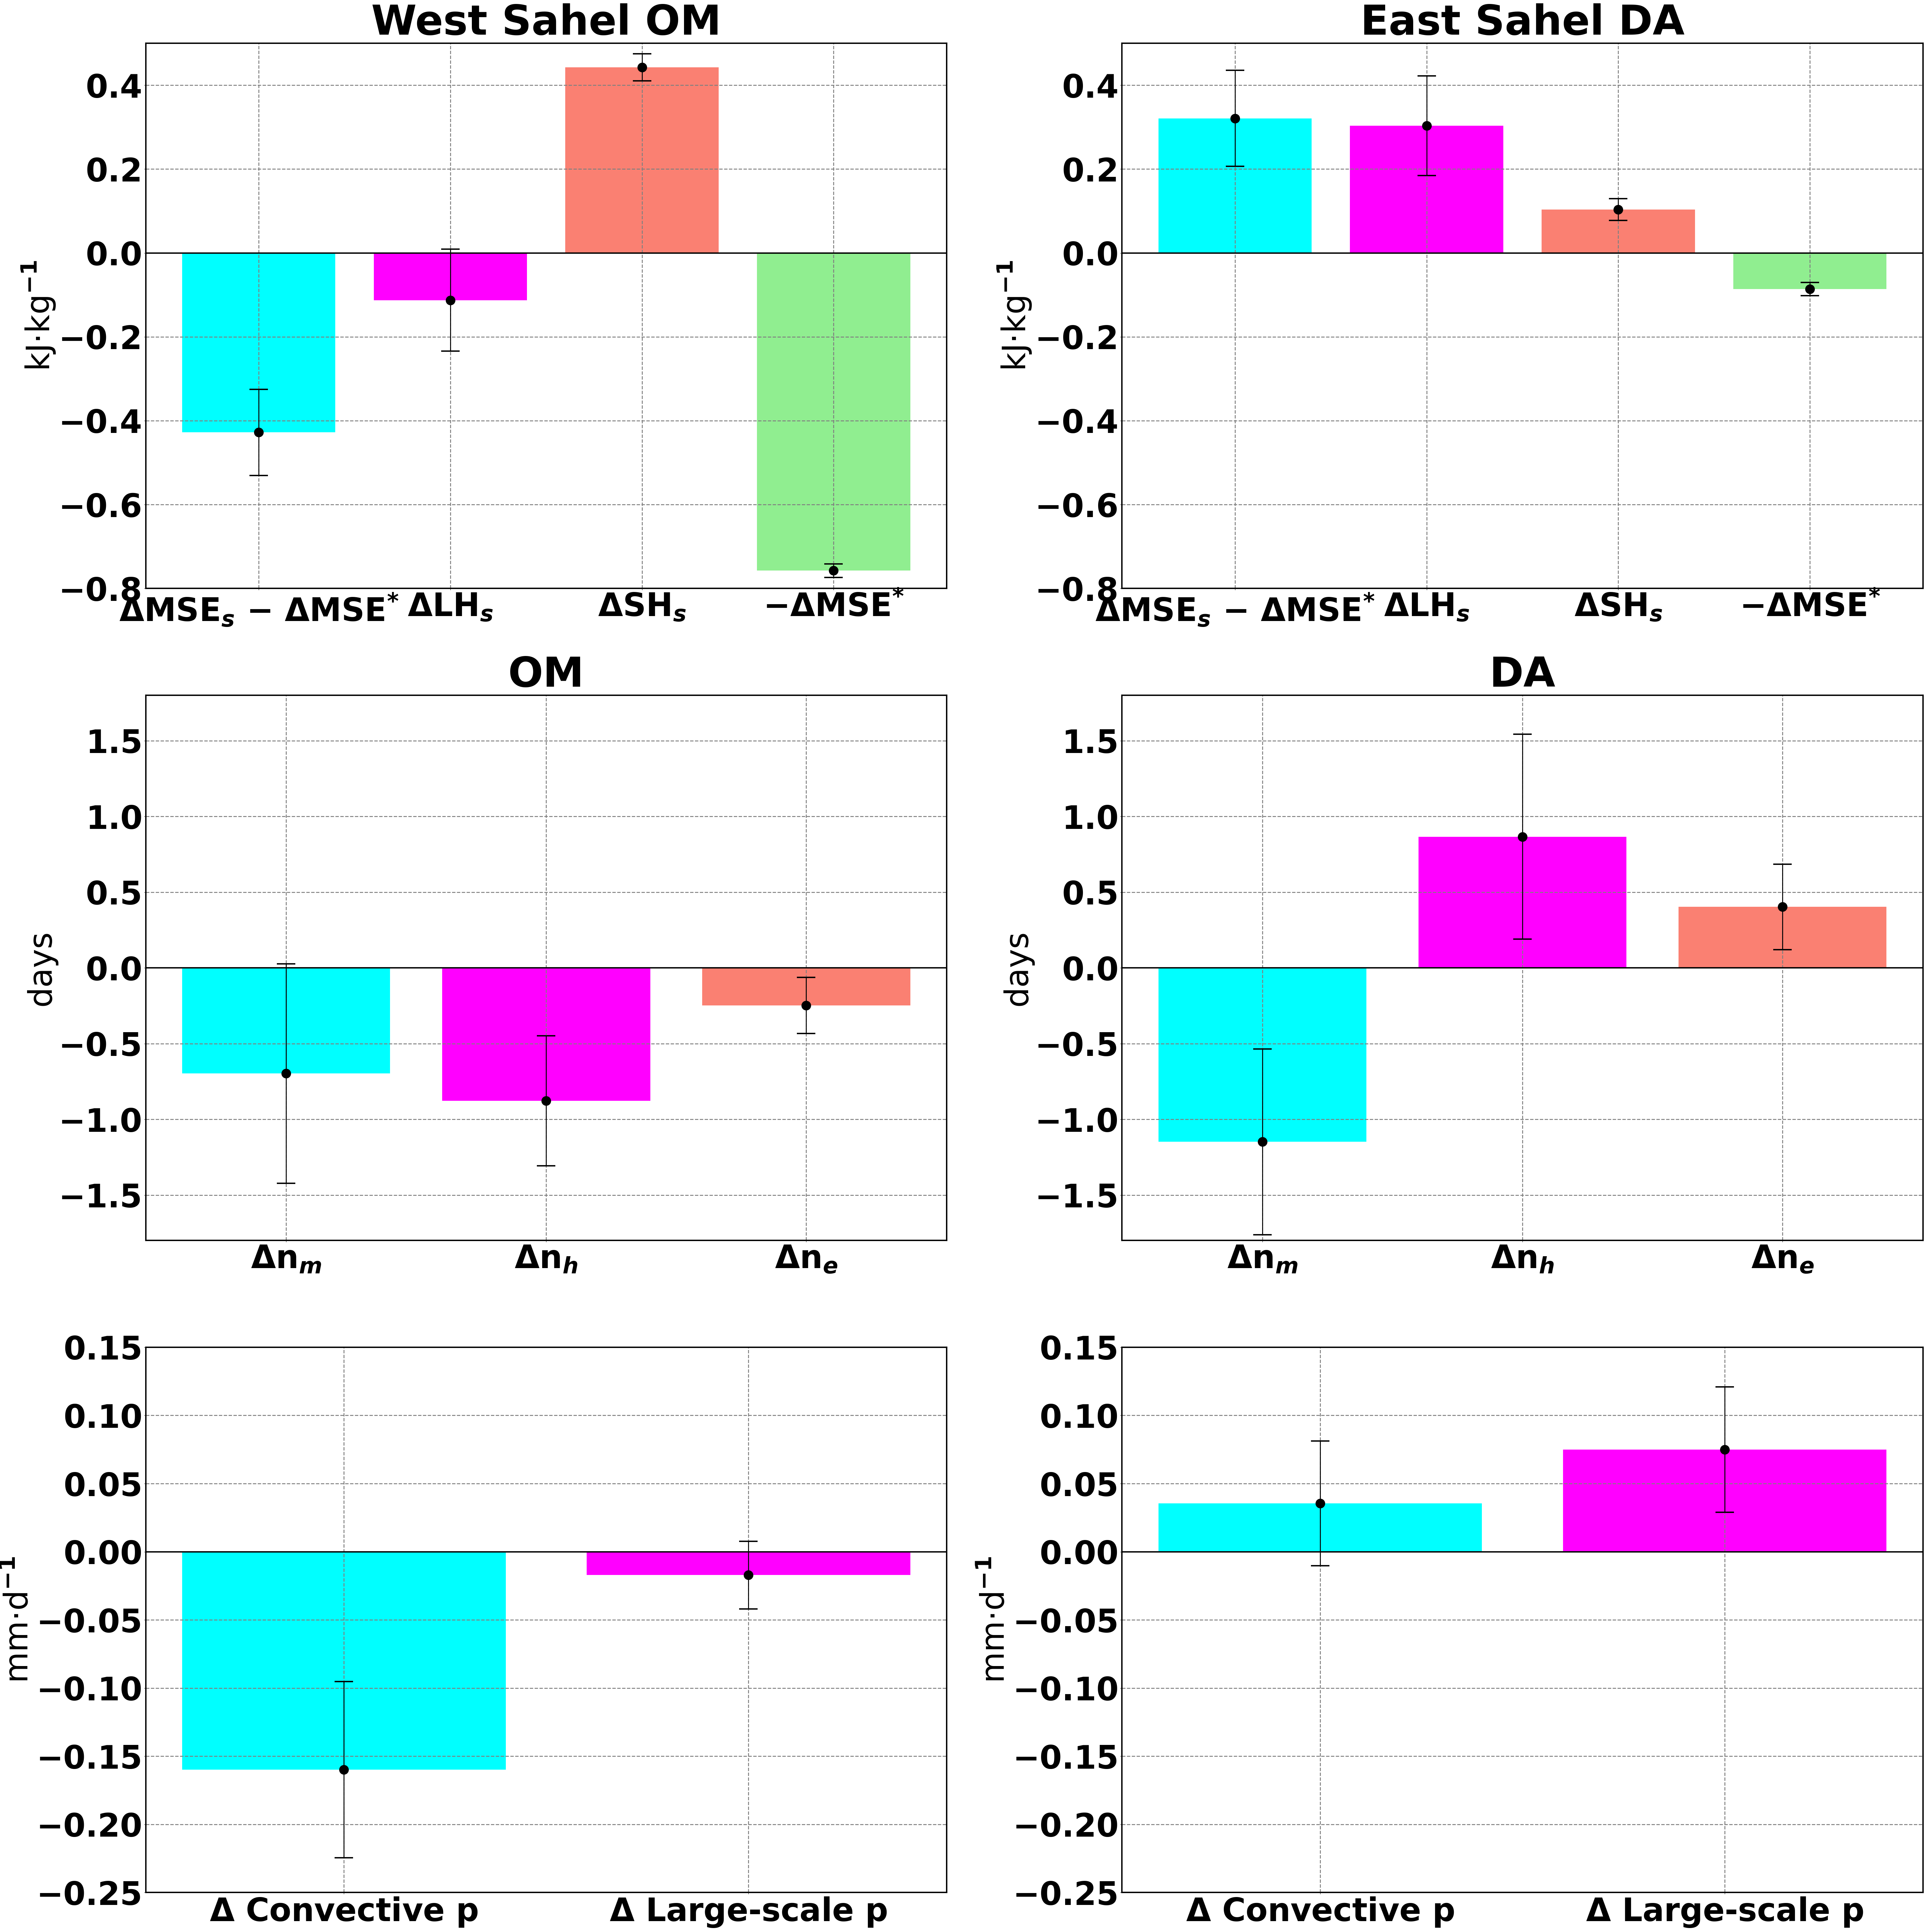

In [97]:
# Plot

vmin_value = -250
vmax_value = 250
alpha = 0.05

precip_levels_pos = [0.05, 0.1, 0.2, 0.4]
precip_levels_neg = [-0.4, -0.2, -0.1, -0.05]


extent = [-50,30,0,32]
levs = np.arange(-5 * 10**(-3), 6 * 10**(-3), 1 * 10**(-3))



fig = plt.figure(figsize=(60,60))

ft = 80
font = {'family' : 'calibri',
       'weight': 'bold',
       'size': 55}
plt.rc('font', **font)
plt.rc('axes',edgecolor='k',linewidth=3)


ax1 = fig.add_subplot(3,2,1)

color = ['cyan', 'magenta', 'salmon','lightgreen', 'magenta', 'salmon']

ax1.bar([2,3,4,5], [(ds_ghgom2004_JAS_WS['MSE_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['MSE_sol_mean'].mean(dim = 'time')) + (-ds_ghgom2004_JAS_WS['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['MSE_sat_mean'].mean(dim = 'time')) + 2* (-ds_ghgom2004_JAS_WS['LH_sol_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['LH_sol_mean'].mean(dim = 'time')),  (-ds_ghgom2004_JAS_WS['LH_sol_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['LH_sol_mean'].mean(dim = 'time')),(ds_ghgom2004_JAS_WS['SH_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['SH_sol_mean'].mean(dim = 'time')),(-ds_ghgom2004_JAS_WS['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['MSE_sat_mean'].mean(dim = 'time'))], align = 'center', color = color)
ax1.errorbar([2,3,4,5], [(ds_ghgom2004_JAS_WS['MSE_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['MSE_sol_mean'].mean(dim = 'time')) + (-ds_ghgom2004_JAS_WS['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['MSE_sat_mean'].mean(dim = 'time')) + + 2* (-ds_ghgom2004_JAS_WS['LH_sol_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['LH_sol_mean'].mean(dim = 'time')),  (-ds_ghgom2004_JAS_WS['LH_sol_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['LH_sol_mean'].mean(dim = 'time')),(ds_ghgom2004_JAS_WS['SH_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['SH_sol_mean'].mean(dim = 'time')),(-ds_ghgom2004_JAS_WS['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_WS['MSE_sat_mean'].mean(dim = 'time'))] , yerr= [np.sqrt(err_MSE_sat_WS**2 + err_MSE_sol_WS**2), err_LH_sol_WS, err_SH_sol_WS, err_MSE_sat_WS] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.set_ylim([-0.8,0.5])
ax1.set_title('West Sahel OM', fontsize = ft+10, weight = 'bold')
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3,4,5])
ax1.set_xticklabels([r'$\Delta$MSE$_s$ $-$ $\Delta$MSE$^{*}$', r'$\Delta$LH$_s$', r'$\Delta$SH$_s$', r'$-$$\Delta$MSE$^{*}$'],  fontsize = 50)
ax1.set_ylabel(r'kJ·kg$^{-1}$', fontsize = ft -10)
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)

ax1 = fig.add_subplot(3,2,2)

color = ['cyan', 'magenta', 'salmon','lightgreen', 'magenta', 'salmon']

ax1.bar([2,3,4,5], [(ds_ghgda2004_JAS_ES['MSE_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['MSE_sol_mean'].mean(dim = 'time')) + (-ds_ghgda2004_JAS_ES['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_ES['MSE_sat_mean'].mean(dim = 'time')),  (ds_ghgda2004_JAS_ES['LH_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['LH_sol_mean'].mean(dim = 'time')),(ds_ghgda2004_JAS_ES['SH_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['SH_sol_mean'].mean(dim = 'time')),(-ds_ghgda2004_JAS_ES['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_ES['MSE_sat_mean'].mean(dim = 'time'))], align = 'center', color = color)
ax1.errorbar([2,3,4,5], [(ds_ghgda2004_JAS_ES['MSE_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['MSE_sol_mean'].mean(dim = 'time')) + (-ds_ghgda2004_JAS_ES['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_ES['MSE_sat_mean'].mean(dim = 'time')),  (ds_ghgda2004_JAS_ES['LH_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['LH_sol_mean'].mean(dim = 'time')),(ds_ghgda2004_JAS_ES['SH_sol_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['SH_sol_mean'].mean(dim = 'time')),(-ds_ghgda2004_JAS_ES['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlghg1980_JAS_ES['MSE_sat_mean'].mean(dim = 'time'))] , yerr= [np.sqrt(err_MSE_sat_ES**2 + err_MSE_sol_ES**2), err_LH_sol_ES, err_SH_sol_ES, err_MSE_sat_ES] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.set_ylim([-0.8,0.5])
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3,4,5])
ax1.set_title('East Sahel DA', fontsize = ft+10, weight = 'bold')
ax1.set_xticklabels([r'$\Delta$MSE$_s$ $-$ $\Delta$MSE$^{*}$', r'$\Delta$LH$_s$', r'$\Delta$SH$_s$', r'$-$$\Delta$MSE$^{*}$'], fontsize = 50)
ax1.set_ylabel(r'kJ·kg$^{-1}$', fontsize = ft -10)

ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)

ax1 = fig.add_subplot(3,2,5)

color = ['cyan', 'magenta', 'salmon','cyan', 'magenta', 'salmon']

ax1.bar([2,3], [(ds_ghgom2004_JAS_WS['pluc_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['pluc_mean'].mean(dim = 'time')),  (ds_ghgom2004_JAS_WS['plul_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['plul_mean'].mean(dim = 'time')),], align = 'center', color = color)
ax1.errorbar([2,3], [(ds_ghgom2004_JAS_WS['pluc_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['pluc_mean'].mean(dim = 'time')),  (ds_ghgom2004_JAS_WS['plul_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_WS['plul_mean'].mean(dim = 'time')),] , yerr= [err_pluc_WS, err_plul_WS] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3])
ax1.set_ylim([-0.25,0.15])
ax1.set_xticklabels([r'$\Delta$ Convective p', r'$\Delta$ Large-scale p'], fontsize = 50)
ax1.set_ylabel(r'mm·d$^{-1}$',fontsize = ft -10)
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)
ax1 = fig.add_subplot(3,2,6)

color = ['cyan', 'magenta', 'salmon','cyan', 'magenta', 'salmon']

ax1.bar([2,3], [(ds_ghgda2004_JAS_ES['pluc_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['pluc_mean'].mean(dim = 'time')),  (ds_ghgda2004_JAS_ES['plul_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['plul_mean'].mean(dim = 'time')),], align = 'center', color = color)
ax1.errorbar([2,3], [(ds_ghgda2004_JAS_ES['pluc_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['pluc_mean'].mean(dim = 'time')),  (ds_ghgda2004_JAS_ES['plul_mean'].mean(dim = 'time') - ds_ctrlghg1980_JAS_ES['plul_mean'].mean(dim = 'time')),] , yerr= [err_pluc_ES, err_plul_ES] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3])
ax1.set_ylim([-0.25,0.15])
ax1.set_xticklabels([r'$\Delta$ Convective p', r'$\Delta$ Large-scale p'], fontsize = 50)
ax1.set_ylabel(r'mm·d$^{-1}$', fontsize = ft -10 )
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)

ax1 = fig.add_subplot(3,2,3)

color = ['cyan', 'magenta', 'salmon','cyan', 'magenta', 'salmon']

ax1.bar([2,3,4], [(ds_ghgom2004_JAS_WS['n_moderate_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_WS['n_moderate_mean'].mean(dim = 'year')),  (ds_ghgom2004_JAS_WS['n_heavy_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_WS['n_heavy_mean'].mean(dim = 'year')), (ds_ghgom2004_JAS_WS['n_extreme_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_WS['n_extreme_mean'].mean(dim = 'year'))], align = 'center', color = color)
ax1.errorbar([2,3,4], [(ds_ghgom2004_JAS_WS['n_moderate_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_WS['n_moderate_mean'].mean(dim = 'year')),  (ds_ghgom2004_JAS_WS['n_heavy_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_WS['n_heavy_mean'].mean(dim = 'year')), (ds_ghgom2004_JAS_WS['n_extreme_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_WS['n_extreme_mean'].mean(dim = 'year'))] , yerr= [err_n_moderate_WS, err_n_heavy_WS, err_n_extreme_WS] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3,4])
ax1.set_ylim([-1.8,1.8])
ax1.set_title('OM', fontsize = ft+10, weight = 'bold')
ax1.set_xticklabels([r'$\Delta$n$_m$', r'$\Delta$n$_h$', r'$\Delta$n$_e$'], fontsize = 50)
ax1.set_ylabel('days', fontsize = ft -10)
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)

ax1 = fig.add_subplot(3,2,4)

color = ['cyan', 'magenta', 'salmon','cyan', 'magenta', 'salmon']

ax1.bar([2,3,4], [(ds_ghgda2004_JAS_ES['n_moderate_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_ES['n_moderate_mean'].mean(dim = 'year')),  (ds_ghgda2004_JAS_ES['n_heavy_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_ES['n_heavy_mean'].mean(dim = 'year')), (ds_ghgda2004_JAS_ES['n_extreme_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_ES['n_extreme_mean'].mean(dim = 'year'))], align = 'center', color = color)
ax1.errorbar([2,3,4], [(ds_ghgda2004_JAS_ES['n_moderate_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_ES['n_moderate_mean'].mean(dim = 'year')),  (ds_ghgda2004_JAS_ES['n_heavy_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_ES['n_heavy_mean'].mean(dim = 'year')), (ds_ghgda2004_JAS_ES['n_extreme_mean'].mean(dim = 'year') - ds_ctrlghg1980_JAS_ES['n_extreme_mean'].mean(dim = 'year'))] , yerr= [err_n_moderate_ES, err_n_heavy_ES, err_n_extreme_ES] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3,4])
ax1.set_ylim([-1.8,1.8])
ax1.set_title('DA', fontsize = ft+10, weight = 'bold')
ax1.set_ylabel('days', fontsize = ft -10)
ax1.set_xticklabels([r'$\Delta$n$_m$', r'$\Delta$n$_h$', r'$\Delta$n$_e$'], fontsize = 50)
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)
fig.tight_layout()

plt.savefig('/home/pfernand/Postdoc/Results/Forced_simulations/GHG/Intraseasonal_features_GHG.jpg', bbox_inches = 'tight', dpi = 150)




In [76]:
# For aerosols, also include vertical velocity 

ds_aerom2004_NMC = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/AEROM2004ann/MO/AEROM2004ann_1980101_20791230_JAS_histmthNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})
ds_ctrlaer1980_NMC = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER1980ann/MO/CTRLAER1980ann_19800101_20791230_JAS_histmthNMC.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})


In [77]:
ds_aerom2004_NMC_SMC = ds_aerom2004_NMC.sel(lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])).mean(dim = 'lon', skipna = True)
ds_ctrlaer1980_NMC_SMC = ds_ctrlaer1980_NMC.sel(lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])).mean(dim = 'lon', skipna = True)


t_stat_aerom_w_20041980, p_value_aerom_w_20041980 = stats.ttest_ind(ds_aerom2004_NMC_SMC.wap.values, ds_ctrlaer1980_NMC_SMC.wap.values, axis = 0, equal_var=False)


/tmp/ipykernel_1530740/1877987033.py:41: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax1.contour(ds_ctrlaer1980_NMC.lat.values, ds_ctrlaer1980_NMC.plev.values/100, (ds_ctrlaer1980_NMC_SMC.wap.mean(dim = ('time'), skipna = True)), levels = np.arange(-0.15,0,0.025), colors = 'gray', linewidths = 5, linestyle = '--')
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont:

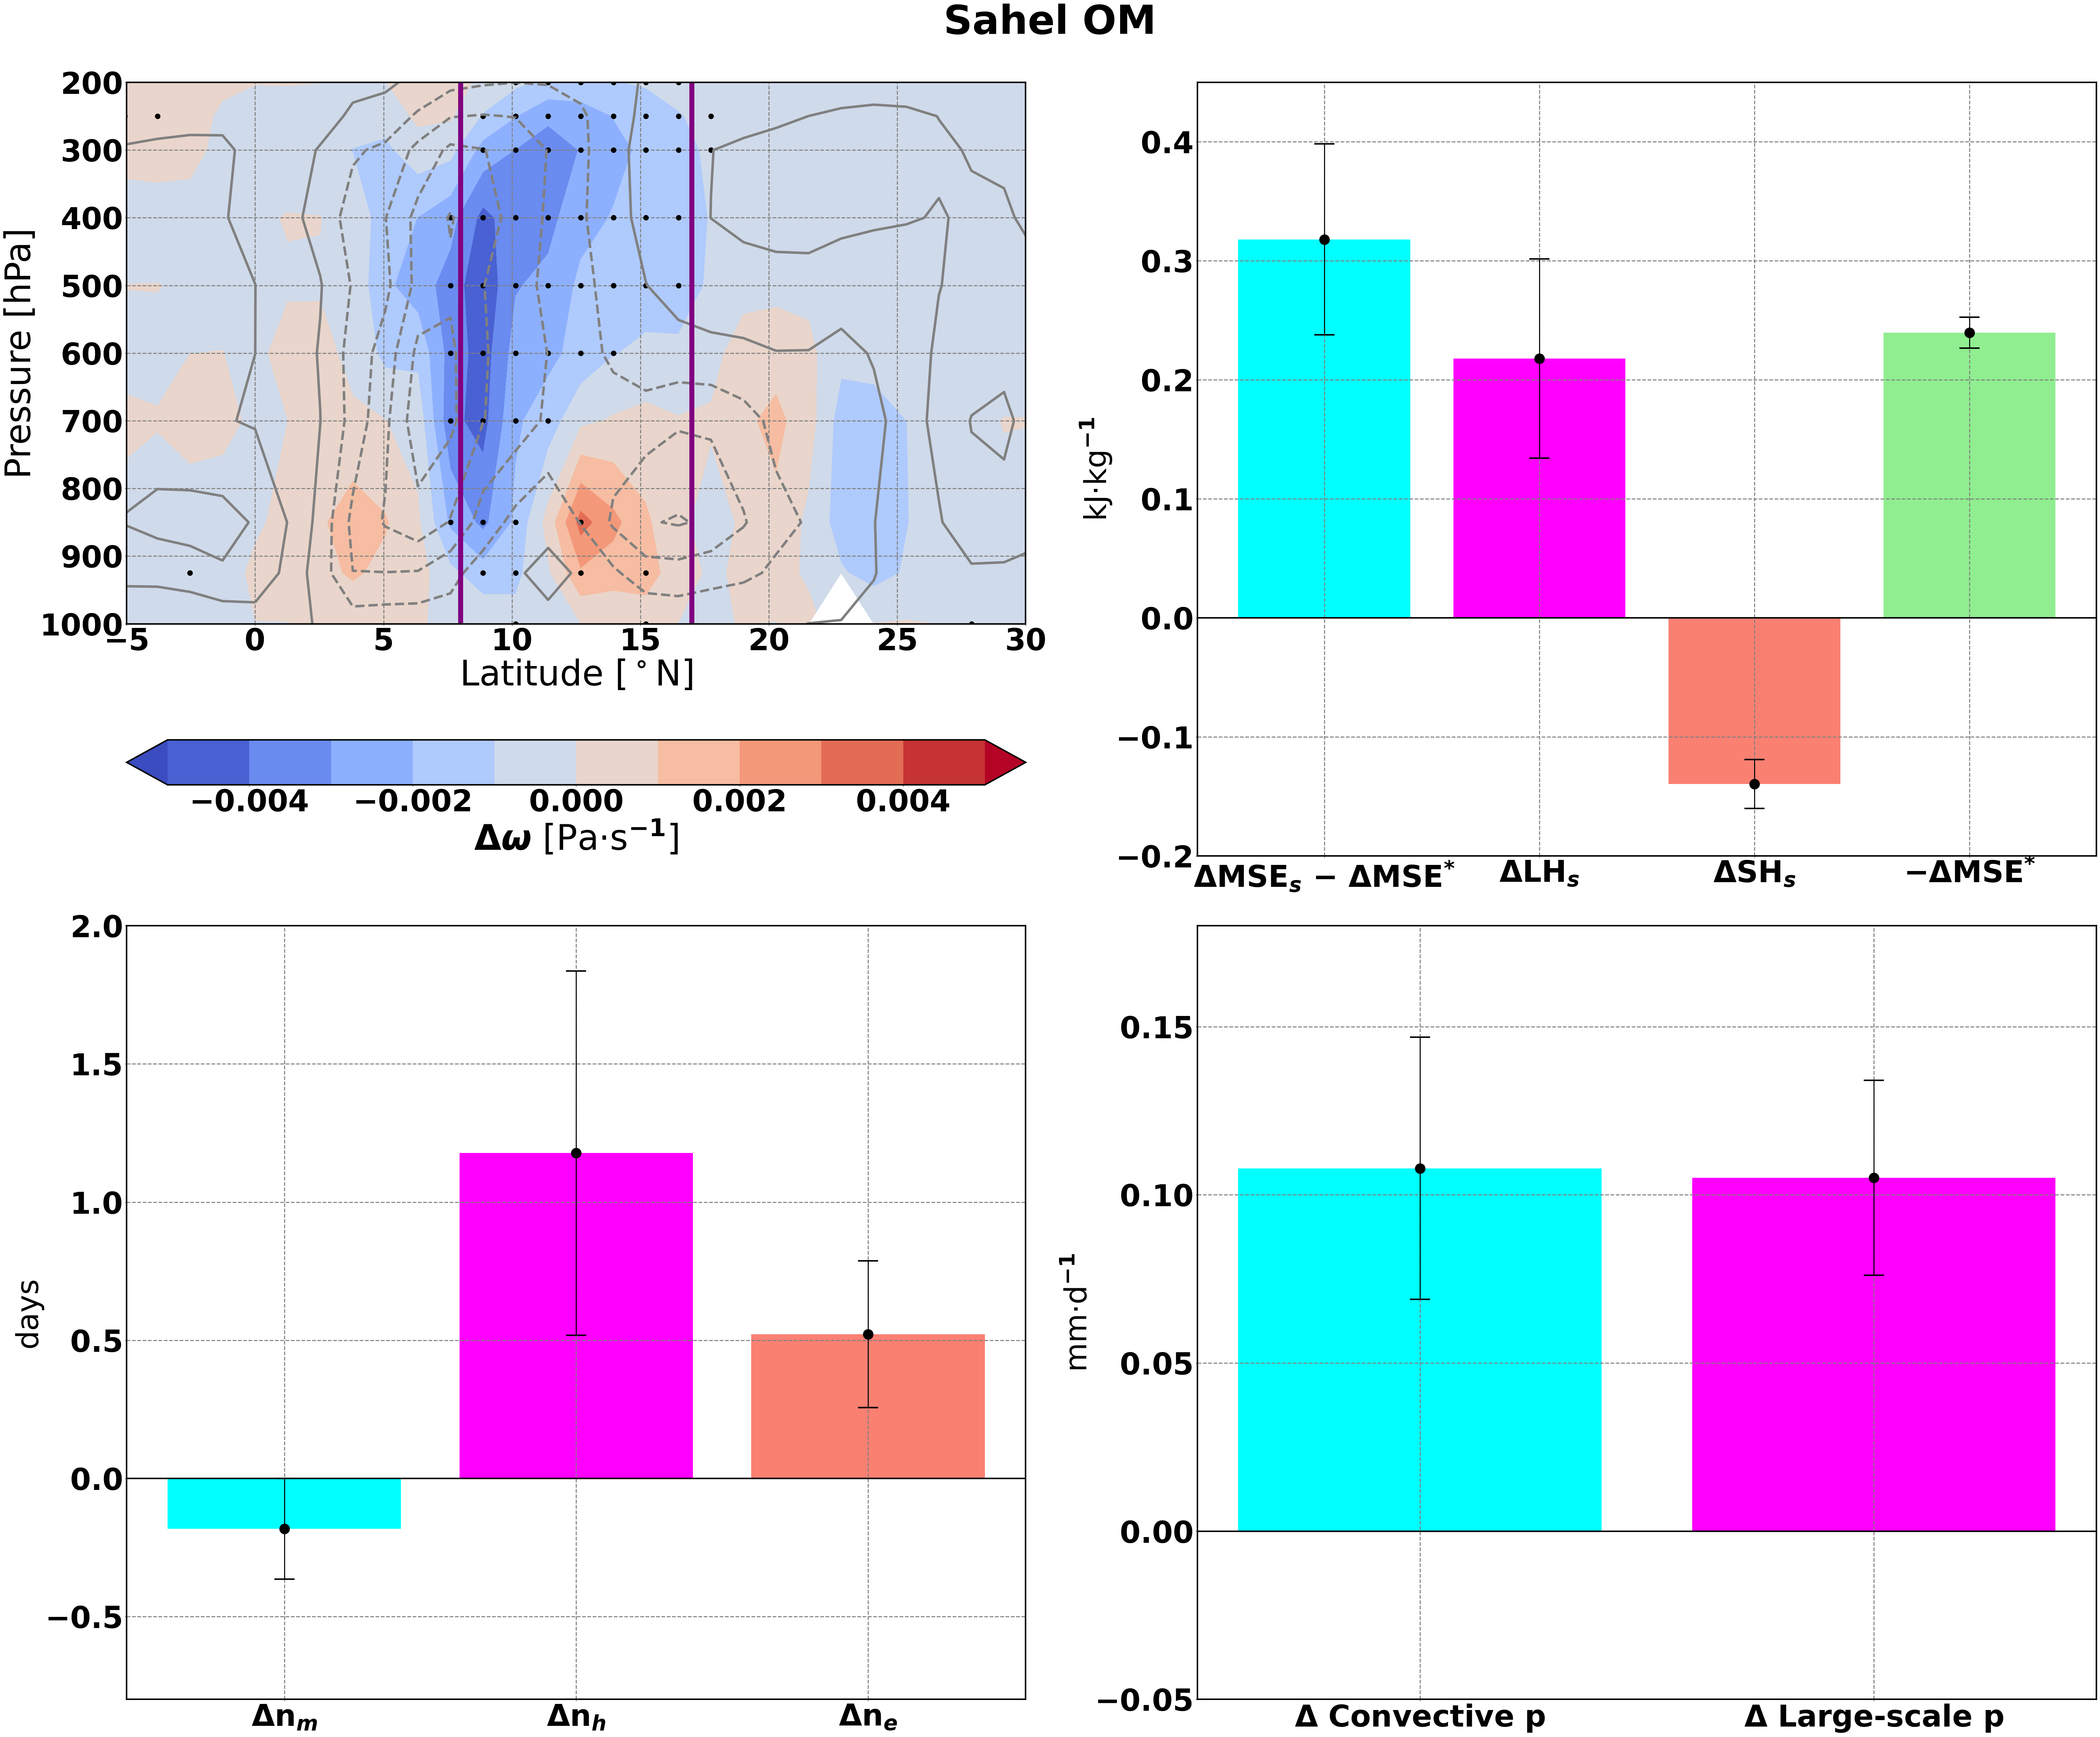

In [101]:
# Plot

vmin_value = -250
vmax_value = 250
alpha = 0.05

precip_levels_pos = [0.05, 0.1, 0.2, 0.4]
precip_levels_neg = [-0.4, -0.2, -0.1, -0.05]


extent = [-50,30,0,32]
levs = np.arange(-5 * 10**(-3), 6 * 10**(-3), 1 * 10**(-3))



fig = plt.figure(figsize=(60,50))

ft = 70
font = {'family' : 'calibri',
       'weight': 'bold',
       'size': 60}
plt.rc('font', **font)
plt.rc('axes',edgecolor='k',linewidth=3)

ax1 = fig.add_subplot(2,2,1)


im = ax1.contourf(ds_ctrlaer1980_NMC.lat.values, ds_ctrlaer1980_NMC.plev.values/100, (ds_aerom2004_NMC_SMC.wap.mean(dim = ('time'), skipna = True) - ds_ctrlaer1980_NMC_SMC.wap.mean(dim = ('time'), skipna = True)), levels = levs, extend = 'both', cmap = "coolwarm")
cbar = fig.colorbar(im, ax=ax1, orientation = 'horizontal')
cbar.set_label(r"$\Delta$$\omega$ [Pa·s$^{-1}$]", fontsize = ft)
cbar.ax.tick_params(labelsize=ft-10)



LON, LAT = np.meshgrid(ds_ctrlaer1980_NMC.lat.values, ds_ctrlaer1980_NMC.plev.values/100)
lon_masked = ma.masked_where((np.isnan(p_value_aerom_w_20041980)) | ((p_value_aerom_w_20041980 > alpha)), LON)
lat_masked = ma.masked_where((np.isnan(p_value_aerom_w_20041980)) | ((p_value_aerom_w_20041980 > alpha)), LAT)
hatch = ax1.plot(np.transpose(lon_masked),np.transpose(lat_masked),'.',color='black',markersize=20)

ax1.contour(ds_ctrlaer1980_NMC.lat.values, ds_ctrlaer1980_NMC.plev.values/100, (ds_ctrlaer1980_NMC_SMC.wap.mean(dim = ('time'), skipna = True)), levels = np.arange(0,0.15,0.025), colors = 'gray', linewidths = 5)
ax1.contour(ds_ctrlaer1980_NMC.lat.values, ds_ctrlaer1980_NMC.plev.values/100, (ds_ctrlaer1980_NMC_SMC.wap.mean(dim = ('time'), skipna = True)), levels = np.arange(-0.15,0,0.025), colors = 'gray', linewidths = 5, linestyle = '--')



ax1.axvline(x = 8 ,color = 'purple', linewidth = 10)
ax1.axvline(x = 17,color = 'purple', linewidth = 10)

ax1.set_ylim([200,1000])
ax1.set_xlim([-5,30])
ax1.set_xlabel(r'Latitude [$^\circ$N]', fontsize = ft)
ax1.set_ylabel(r'Pressure [hPa]', fontsize = ft)
#ax1.set_title(r'Ti', weight = 'bold', fontsize = ft) 
ax1.invert_yaxis()

ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)


ax1 = fig.add_subplot(2,2,2)

color = ['cyan', 'magenta', 'salmon','lightgreen', 'magenta', 'salmon']

ax1.bar([2,3,4,5], [(ds_aerom2004_JAS_Sahel['MSE_sol_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['MSE_sol_mean'].mean(dim = 'time')) + (-ds_aerom2004_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlaer1980_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time')),  (ds_aerom2004_JAS_Sahel['LH_sol_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['LH_sol_mean'].mean(dim = 'time')),(ds_aerom2004_JAS_Sahel['SH_sol_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['SH_sol_mean'].mean(dim = 'time')),(-ds_aerom2004_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlaer1980_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time'))], align = 'center', color = color)
ax1.errorbar([2,3,4,5], [(ds_aerom2004_JAS_Sahel['MSE_sol_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['MSE_sol_mean'].mean(dim = 'time')) + (-ds_aerom2004_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlaer1980_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time')),  (ds_aerom2004_JAS_Sahel['LH_sol_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['LH_sol_mean'].mean(dim = 'time')),(ds_aerom2004_JAS_Sahel['SH_sol_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['SH_sol_mean'].mean(dim = 'time')),(-ds_aerom2004_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time') + ds_ctrlaer1980_JAS_Sahel['MSE_sat_mean'].mean(dim = 'time'))] , yerr= [np.sqrt(err_MSE_sat_Sahel**2 + err_MSE_sol_Sahel**2), err_LH_sol_Sahel, err_SH_sol_Sahel, err_MSE_sat_Sahel] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.set_ylim([-0.2,0.45])
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3,4,5])
ax1.set_xticklabels([r'$\Delta$MSE$_s$ $-$ $\Delta$MSE$^{*}$', r'$\Delta$LH$_s$', r'$\Delta$SH$_s$', r'$-$$\Delta$MSE$^{*}$'], fontsize = 20)
ax1.set_ylabel(r'kJ·kg$^{-1}$')
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)


ax1 = fig.add_subplot(2,2,4)

color = ['cyan', 'magenta', 'salmon','cyan', 'magenta', 'salmon']

ax1.bar([2,3], [(ds_aerom2004_JAS_Sahel['pluc_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['pluc_mean'].mean(dim = 'time')),  (ds_aerom2004_JAS_Sahel['plul_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['plul_mean'].mean(dim = 'time')),], align = 'center', color = color)
ax1.errorbar([2,3], [(ds_aerom2004_JAS_Sahel['pluc_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['pluc_mean'].mean(dim = 'time')),  (ds_aerom2004_JAS_Sahel['plul_mean'].mean(dim = 'time') - ds_ctrlaer1980_JAS_Sahel['plul_mean'].mean(dim = 'time')),] , yerr= [err_pluc_Sahel, err_plul_Sahel] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3])
ax1.set_ylim([-0.05,0.18])
ax1.set_xticklabels([r'$\Delta$ Convective p', r'$\Delta$ Large-scale p'], fontsize = 30)
ax1.set_ylabel(r'mm·d$^{-1}$',size=ft-10)
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)


ax1 = fig.add_subplot(2,2,3)

color = ['cyan', 'magenta', 'salmon','cyan', 'magenta', 'salmon']

ax1.bar([2,3,4], [(ds_aerom2004_JAS_Sahel['n_moderate_mean'].mean(dim = 'year') - ds_ctrlaer1980_JAS_Sahel['n_moderate_mean'].mean(dim = 'year')),  (ds_aerom2004_JAS_Sahel['n_heavy_mean'].mean(dim = 'year') - ds_ctrlaer1980_JAS_Sahel['n_heavy_mean'].mean(dim = 'year')), (ds_aerom2004_JAS_Sahel['n_extreme_mean'].mean(dim = 'year') - ds_ctrlaer1980_JAS_Sahel['n_extreme_mean'].mean(dim = 'year'))], align = 'center', color = color)
ax1.errorbar([2,3,4], [(ds_aerom2004_JAS_Sahel['n_moderate_mean'].mean(dim = 'year') - ds_ctrlaer1980_JAS_Sahel['n_moderate_mean'].mean(dim = 'year')),  (ds_aerom2004_JAS_Sahel['n_heavy_mean'].mean(dim = 'year') - ds_ctrlaer1980_JAS_Sahel['n_heavy_mean'].mean(dim = 'year')), (ds_aerom2004_JAS_Sahel['n_extreme_mean'].mean(dim = 'year') - ds_ctrlaer1980_JAS_Sahel['n_extreme_mean'].mean(dim = 'year'))] , yerr= [err_n_moderate_Sahel/3, err_n_heavy_Sahel, err_n_extreme_Sahel] , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.grid(linestyle='--', color='gray', linewidth=2)
ax1.axhline(y = 0, linewidth = 3, color = 'black')
ax1.set_xticks([2,3,4])
ax1.set_ylim([-0.8,2])
ax1.set_xticklabels([r'$\Delta$n$_m$', r'$\Delta$n$_h$', r'$\Delta$n$_e$'], fontsize = 50)
ax1.set_ylabel('days')
ax1.tick_params(axis='x', labelsize=ft-10)
ax1.tick_params(axis='y', labelsize=ft-10)

fig.suptitle('Sahel OM', weight = 'bold', fontsize = ft + 10)
fig.tight_layout()

plt.savefig('/home/pfernand/Postdoc/Results/Forced_simulations/AER/Intraseasonal_features_AER.jpg', bbox_inches = 'tight', dpi = 150)

